# Anomaly Detection using Autoencoder

This work is inspired by the medium blog:
* [Autoencoders and Testing their Potential in Anomaly Detection](https://medium.com/@amnahhmohammed/autoencoders-and-testing-their-potential-in-anomaly-detection-09135140fd56)
* [code](https://github.com/amnahhebrahim/Autoencoders-for-Anomaly-Detection/blob/main/Engine_Fault_DB_Dataset_Autoencoder_for_Anomaly_Detection.ipynb)

We use Autoencoder:
1. Train normal data
2. Identify anomaly score (reconstruct errors) distributions
3. Determine the **threshold** of anomaly score.

And we can see the faulty data has very different score distribution.

The data is from the repo: [EngineFaultDB: A Novel Dataset for Automotive Engine Fault Classification and Baseline Results](https://github.com/leoxthomas/EngineFaultDB)

In [1]:
#import necessary libraries
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

dataset=pd.read_csv("EngineFaultDB_Final.csv")
dataset.head()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,0,3.549,1.889,7.428,5.227,1192.769,3.057,11.720,24.901,0.460,196.089,14.356,1.080,1.047,15.385
1,0,3.559,1.899,7.646,5.327,1145.191,2.914,11.276,25.030,0.478,196.283,14.492,1.107,1.083,15.926
2,0,3.539,1.899,7.578,5.100,1208.505,2.976,11.926,24.213,0.464,200.367,14.443,1.099,1.072,15.754
3,0,3.519,1.889,7.371,5.255,1164.127,2.908,11.786,24.407,0.471,195.345,13.853,1.076,1.006,14.787
4,0,3.549,1.879,7.405,5.177,1172.032,2.898,12.169,24.875,0.468,194.979,13.752,1.060,0.984,14.470


In [4]:
dataset.shape

(55999, 15)

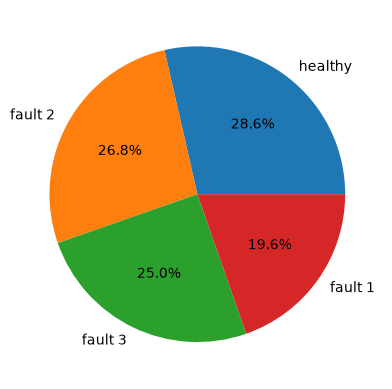

In [2]:
count= dataset['Fault'].value_counts() #get the frequency of different labels
plt.pie(x=count.values, labels=['healthy','fault 2', 'fault 3','fault 1'], autopct='%1.1f%%')
plt.show()

* **No fault** indicated by “0” in the dataset’s label column “Fault”
* **Rich mixture fault** indicated by “1” in the dataset’s label column “Fault”
* **Lean mixture fault** indicated by “2” in the dataset’s label column “Fault”
* **Low voltage fault** indicated by “3” in the dataset’s label column “Fault”


In [106]:
from sklearn.model_selection import train_test_split

dataset = dataset.sample(frac=1)
train, test = train_test_split(dataset, test_size=0.2, random_state=42)

print(train.shape, test.shape)

(44799, 15) (11200, 15)


## Normal (Healthy) Dataset

In [60]:
#Create a dataset for the healthy data:
healthy_dataset = train[train['Fault']== 0] #Healthy Dataset
#Remove the "Fault column" as we don't need it to understand the behavior of the data:
healthy_dataset = healthy_dataset.drop("Fault", axis=1)
# This is the feature vector that goes to the neural net
healthy_input = healthy_dataset.values

In [107]:
from sklearn.model_selection import train_test_split

healthy_train, healthy_val = train_test_split(
        healthy_input, test_size=0.2, random_state=42)

print(f"Good train count: {len(healthy_train)}")
print(f"Good test count: {len(healthy_val)}")

Good train count: 10216
Good test count: 2555


In [108]:
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline

# configure our pipeline
pipeline = Pipeline([('normalizer', Normalizer()),
                     ('scaler', MinMaxScaler())])

pipeline.fit(healthy_train);
# transform the training and validation data with these parameters
train_transformed = pipeline.transform(healthy_train)
val_transformed = pipeline.transform(healthy_val)

In [109]:
train_transformed.shape, val_transformed.shape

((10216, 14), (2555, 14))

In [110]:
type(train_transformed)

numpy.ndarray

## Using Pytroch for AutoEncoder

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

class AnomalyAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(AnomalyAutoencoder, self).__init__()
        
        # The Encoder shrinks the data down to a latent representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 3)
            # nn.ReLU(),
            # nn.Linear(16, 8)  # Bottleneck / Latent Space
        )
        
        # The Decoder attempts to reconstruct the original input
        self.decoder = nn.Sequential(
            nn.Linear(3, 10),
            nn.ReLU(),
            # nn.Linear(16, 32),
            # nn.ReLU(),
            nn.Linear(10, input_dim),
            # Sigmoid assumes your input features are scaled between [0, 1]
            nn.Sigmoid() 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [21]:
def train_autoencoder(model, X_train_tensor, epochs=100, batch_size=64, lr=0.001):
    # Prepare DataLoader
    dataset = TensorDataset(X_train_tensor, X_train_tensor) # Input is target
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.train() # Set to training mode
    loss_history = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_features, _ in dataloader:
            # 1. Forward pass
            reconstructed = model(batch_features)
            
            # 2. Calculate loss (Mean Squared Error)
            loss = criterion(reconstructed, batch_features)
            
            # 3. Backward pass and optimization
            optimizer.zero_grad() # Clear old gradients
            loss.backward()       # Compute new gradients
            optimizer.step()      # Update weights
            
            epoch_loss += loss.item()

        # Calculate the average loss for this entire epoch
        avg_epoch_loss = epoch_loss / len(dataloader)
        
        loss_history.append(avg_epoch_loss)
        
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.4f}')
            
    return model, loss_history


def get_anomaly_scores(model, X_tensor):
    model.eval() # Set to evaluation mode
    with torch.no_grad(): # Disable gradient tracking for speed/memory
        reconstructed = model(X_tensor)
        
        # Calculate MSE per row (keep dimensions intact)
        # Assuming X_tensor shape is (batch_size, features)
        mse_per_row = torch.mean((X_tensor - reconstructed) ** 2, dim=1)
        
    return mse_per_row.numpy()

In [111]:
input_dim = train_transformed.shape[1]

X_train_tensor = torch.FloatTensor(train_transformed)
X_val_tensor = torch.FloatTensor(val_transformed)

BATCH_SIZE = 64
EPOCHS = 100

# Initialize and train
model = AnomalyAutoencoder(input_dim)
trained_model, loss_history = train_autoencoder(
    model,
    X_train_tensor,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)


Epoch [10/100], Loss: 0.0052
Epoch [20/100], Loss: 0.0025
Epoch [30/100], Loss: 0.0020
Epoch [40/100], Loss: 0.0018
Epoch [50/100], Loss: 0.0015
Epoch [60/100], Loss: 0.0013
Epoch [70/100], Loss: 0.0013
Epoch [80/100], Loss: 0.0012
Epoch [90/100], Loss: 0.0012
Epoch [100/100], Loss: 0.0012


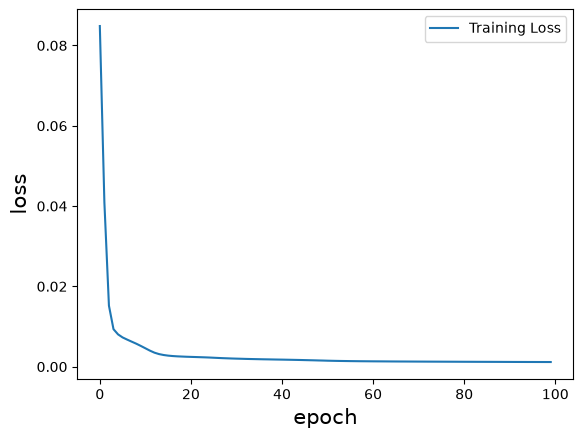

In [112]:
plt.plot(loss_history, label="Training Loss")
plt.xlabel("epoch", fontsize=15)
plt.ylabel("loss", fontsize=15)
# plt.plot(trained_model.history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()

## Normal Data Anomaly Score

In [113]:

# Define the anomaly threshold dynamically based on the training data
# e.g., set the threshold at the 99th percentile of the training errors
train_anomaly_scores = get_anomaly_scores(trained_model, X_train_tensor)
val_anomaly_scores = get_anomaly_scores(trained_model, X_val_tensor)

print(train_anomaly_scores.shape, val_anomaly_scores.shape)

threshold = np.percentile(train_anomaly_scores, 99)

print(f"threshold score: {round(threshold, 4)}")

# Flag test instances as anomalies
predictions = (val_anomaly_scores > threshold).astype(int)

(10216,) (2555,)
threshold score: 0.005499999970197678


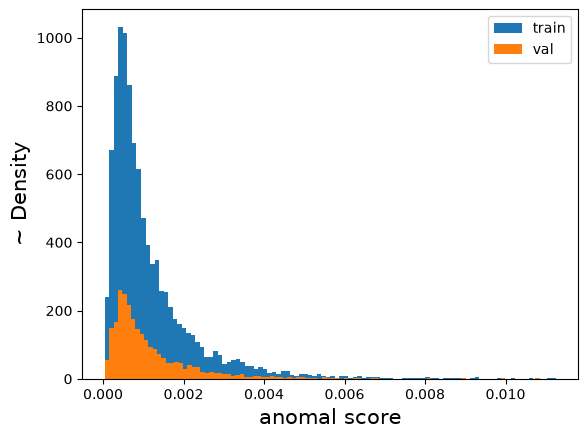

In [118]:
plt.hist(train_anomaly_scores, bins=100, label="train")
plt.hist(val_anomaly_scores, bins=100, label="val")
plt.xlabel("anomal score", fontsize=15)
plt.ylabel("~ Density", fontsize=15)
plt.legend()
plt.show()

Both training and test normal data show anomal score, i.e. **reconstruct error** ~ 0.008

## Frault Data Anomaly Score

In [137]:

fault1_dataset = train[train['Fault'] == 1] #Unhealthy Dataset

fault1_dataset= fault1_dataset.drop("Fault", axis=1)
fault_type1= fault1_dataset.values

faulty_transformeddata= pipeline.transform(fault_type1)

faulty_tensor = torch.FloatTensor(faulty_transformeddata)
faulty_anomaly_scores = get_anomaly_scores(trained_model, faulty_tensor)

print(type(faulty_anomaly_scores), faulty_anomaly_scores.shape)


<class 'numpy.ndarray'> (8727,)


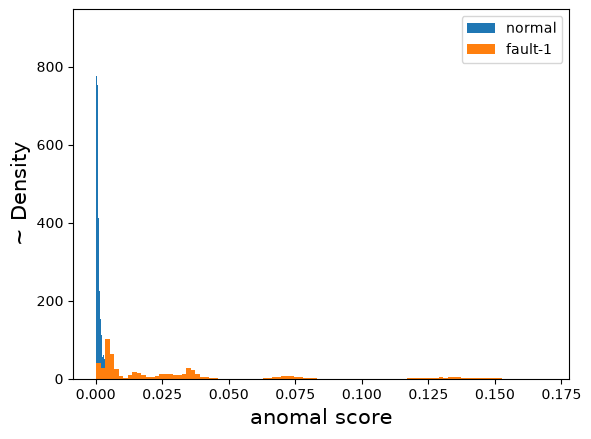

In [138]:
plt.hist(train_anomaly_scores, bins=100, density=True, label="normal")
plt.hist(faulty_anomaly_scores, bins=100, density=True, label="fault-1")
plt.xlabel("anomal score", fontsize=15)
plt.ylabel("~ Density", fontsize=15)
plt.legend()
plt.show()

Now we can the fault data show very different anomal score distribution, i.e. **reconstruct errors** have wider range, up to 0.175.

## Faulty Anomaly Score Evaluation

In [127]:
threshold

np.float32(0.005520505)

In [128]:
test_dataset = test.drop("Fault", axis=1)
test_dataset = test_dataset.values

test_transformed = pipeline.transform(test_dataset)

X_test_tensor = torch.FloatTensor(test_transformed)
test_anomaly_scores = get_anomaly_scores(trained_model, X_test_tensor)
test_anomaly_scores.shape

(11200,)

In [129]:
test_pred = (test_anomaly_scores > threshold).astype(int)

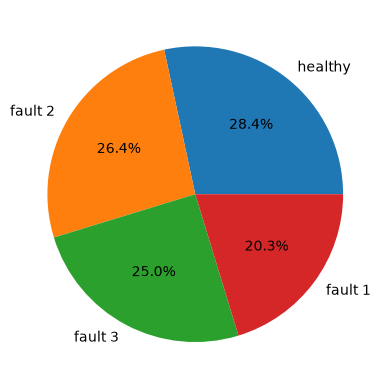

In [136]:
count= test['Fault'].value_counts() #get the frequency of different labels
plt.pie(x=count.values, labels=['healthy','fault 2', 'fault 3','fault 1'], autopct='%1.1f%%')
plt.show()

In [146]:
set(test["Fault"])

{0, 1, 2, 3}

In [163]:
y_test, y_pred = [], []
for x, y in zip(test["Fault"].tolist(), test_anomaly_scores):
    if x == 0:
        # print(x, y)
        y_test.append(0)
        y_pred.append(y)
    elif x == 1:
        # print(x, y)
        y_test.append(1)
        y_pred.append(y)

# y_test = [0 if x == 0 else 1 for x in test["Fault"]]

In [153]:
sum(y_test), len(y_test), set(y_test)

(2271, 5449, {0, 1})

In [154]:
sum(y_pred), len(y_pred), set(y_pred)

(np.int64(1589), 5449, {np.int64(0), np.int64(1)})

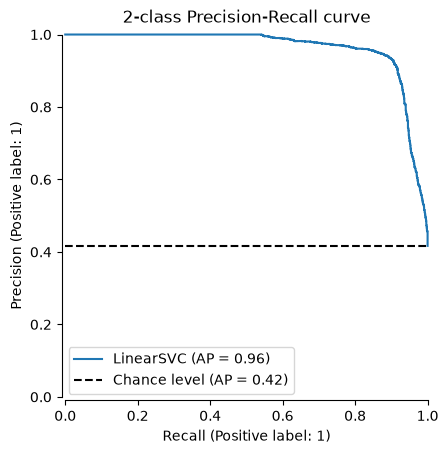

In [164]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_pred, name="LinearSVC", plot_chance_level=True, despine=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")


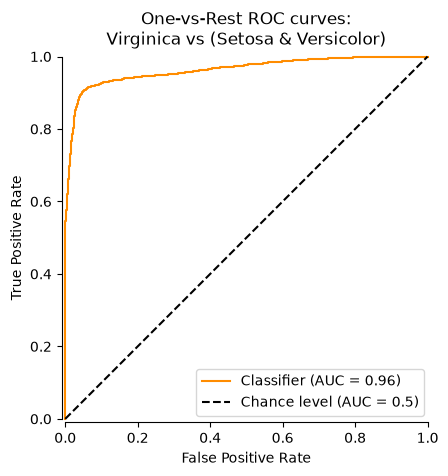

In [165]:
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    y_test,
    y_pred,
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:\nVirginica vs (Setosa & Versicolor)",
)
